<a href="https://colab.research.google.com/github/tewei0328/teach-programming/blob/main/D2_prompt_colab_plot_tsmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 專案：台積電股價走勢分析工具

## 1. 開發計畫 (Plan)
- **目標**：從 Yahoo Finance 獲取台積電 (2330.TW) 過去一年的歷史數據並繪圖。
- **核心功能**：顯示每日收盤價走勢，並加入移動平均線以輔助判斷 [6, 7]。

## 2. 技術規格 (Technical Plan)
- **語言**：Python 3.x
- **套件**：`yfinance` (下載數據)、`pandas` (處理表格)、`matplotlib` (繪圖) [6, 8]。
- **Ticker**：優先使用 `2330.TW` (台股)。

## 3. 執行規則與決策 (Shipping Decisions)
- **數據清理**：必須處理缺失值 (`dropna()`) 以確保繪圖連續 [9]。
- **視覺化規範**：圖表需包含標題、日期軸、價格軸（新台幣）及圖例。
- **避坑指引**：避免使用過時的 API 調用方式，確保符合最新 `yfinance` 語法 [6]。

In [1]:
with open('/content/project1.md', 'r') as f:
    project_md_content = f.read()
print(project_md_content)

# 專案：台積電股價走勢分析工具

## 1. 開發計畫 (Plan)
- **目標**：從 Yahoo Finance 獲取台積電 (2330.TW) 過去一年的歷史數據並繪圖。
- **核心功能**：顯示每日收盤價走勢，並加入移動平均線以輔助判斷 [6, 7]。

## 2. 技術規格 (Technical Plan)
- **語言**：Python 3.x
- **套件**：`yfinance` (下載數據)、`pandas` (處理表格)、`matplotlib` (繪圖) [6, 8]。
- **Ticker**：優先使用 `2330.TW` (台股)。

## 3. 執行規則與決策 (Shipping Decisions)
- **數據清理**：必須處理缺失值 (`dropna()`) 以確保繪圖連續 [9]。
- **視覺化規範**：圖表需包含標題、日期軸、價格軸（新台幣）及圖例。
- **避坑指引**：避免使用過時的 API 調用方式，確保符合最新 `yfinance` 語法 [6]。


In [3]:
import yfinance as yf
import pandas as pd

ts_ticker = '2330.TW'

# 下載台積電過去一年的歷史數據
ts_data = yf.download(ts_ticker, period='1y')

# 顯示數據的前幾行
display(ts_data.head())

/tmp/ipykernel_281/2036331192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ts_data = yf.download(ts_ticker, period='1y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW
Date,,,,,
2025-03-12,972.119324,979.006809,960.312206,964.247912,34184887
2025-03-13,949.488953,988.846008,949.488953,983.926376,37035693
2025-03-14,943.585449,953.424714,939.649743,949.489008,34333748
2025-03-17,954.408630,969.167527,952.440778,961.296115,31491061
2025-03-18,959.845520,966.765107,956.879983,964.788082,21575327


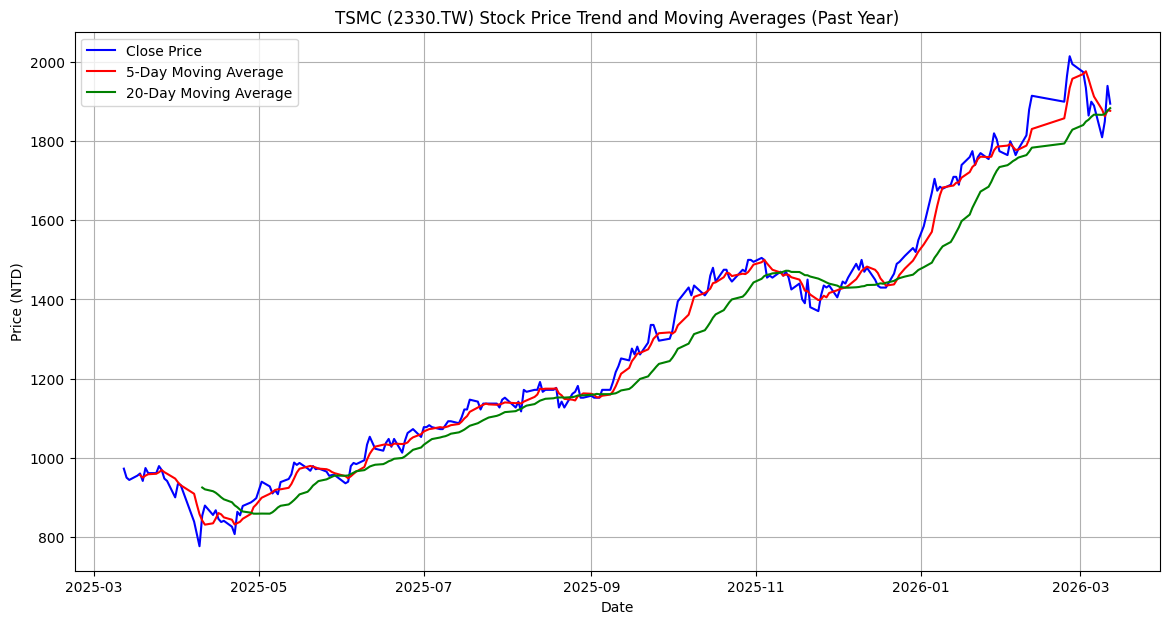

In [9]:
import matplotlib.pyplot as plt

# 計算移動平均線
ts_data['MA5'] = ts_data[('Close', ts_ticker)].rolling(window=5).mean()
ts_data['MA20'] = ts_data[('Close', ts_ticker)].rolling(window=20).mean()

# 繪製股價走勢圖
plt.figure(figsize=(14, 7))
plt.plot(ts_data.index, ts_data[('Close', ts_ticker)], label='Close Price', color='blue')
plt.plot(ts_data.index, ts_data['MA5'], label='5-Day Moving Average', color='red')
plt.plot(ts_data.index, ts_data['MA20'], label='20-Day Moving Average', color='green')

# 添加圖表標題和標籤
plt.title('TSMC (2330.TW) Stock Price Trend and Moving Averages (Past Year)')
plt.xlabel('Date')
plt.ylabel('Price (NTD)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# 檢查 DataFrame 的總行數
print(f"DataFrame 的總行數: {len(ts_data)}")

# 檢查 'MA5' 和 'MA20' 列的非空值數量
print(f"'MA5' 列的非空值數量: {ts_data['MA5'].count()}")
print(f"'MA20' 列的非空值數量: {ts_data['MA20'].count()}")

# 顯示 'MA5' 和 'MA20' 列的前25個值，以確認 NaN 的情況
display(ts_data[['MA5', 'MA20']].head(25))

DataFrame 的總行數: 243
'MA5' 列的非空值數量: 239
'MA20' 列的非空值數量: 224


Price,MA5,MA20
Ticker,,
Date,,
2025-03-12,NaN,NaN
2025-03-13,NaN,NaN
2025-03-14,NaN,NaN
2025-03-17,NaN,NaN
2025-03-18,955.889575,NaN
2025-03-19,949.678467,NaN
2025-03-20,954.517615,NaN
2025-03-21,957.967322,NaN
